In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [44]:
def leer_tdeposit_3d(filename, nx, ny, nz):
    dosis = np.full((nx, ny, nz), np.nan)
    err_rel = np.full((nx, ny, nz), np.nan)

    ix_actual = None
    iy_actual = None
    leyendo_tabla = False
    iz = 0

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:

            m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

            if m:
                ix_actual = int(m.group(1)) - 1
                iy_actual = int(m.group(2)) - 1
                leyendo_tabla = False
                iz = 0
                continue

            if linea.strip().startswith("#  z-lower"):
                leyendo_tabla = True
                iz = 0
                continue

            if leyendo_tabla and iz < nz:
                partes = linea.split()

                if len(partes) != 4:
                    continue

                try:
                    valor_dosis = float(partes[2])
                    valor_err = float(partes[3])
                except ValueError:
                    continue

                if ix_actual is not None and iy_actual is not None:
                    dosis[ix_actual, iy_actual, iz] = valor_dosis
                    err_rel[ix_actual, iy_actual, iz] = valor_err
                    iz += 1

                    if iz == nz:
                        leyendo_tabla = False

    return dosis, err_rel


file_path = "histograma_dosis_sinat.out"

In [45]:
nx = 16
ny = 33
nz = 4

xmin, xmax = -0.8, 0.8
ymin, ymax = -1.65, 1.65
zmin, zmax = 98.38, 98.58


dosissinat, err_relsinat = leer_tdeposit_3d(
    file_path,
    nx,
    ny,
    nz
)


data_dosis1sinat = dosissinat[~np.isnan(dosissinat)]

print("Cantidad total de valores:", len(data_dosis1sinat))
print("Dosis mínima:", np.min(data_dosis1sinat))
print("Dosis máxima:", np.max(data_dosis1sinat))


x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

Cantidad total de valores: 2112
Dosis mínima: 0.0
Dosis máxima: 0.38595


In [47]:
X, Y, Z = np.meshgrid(
    x_centros,
    y_centros,
    z_centros,
    indexing="ij"
)


x0 = 0.0
y0 = 0.0
z0 = 0.5 * (zmin + zmax)

rx = 0.8
ry = 1.65
rz = 1.0

mascara_pouch = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
    <= 1
)

mascara_pouch &= (Z >= zmin) & (Z <= zmax)
dosis_pouchsinat = np.where(
    mascara_pouch,
    dosissinat,
    np.nan
)

err_pouchsinat = np.where(
    mascara_pouch,
    err_relsinat,
    np.nan
)

data_dosis2sinat = dosis_pouchsinat[
    ~np.isnan(dosis_pouchsinat)
]


n_voxeles = len(data_dosis2sinat)

media = np.mean(data_dosis2sinat)
desvio = np.std(data_dosis2sinat)
cv = 100 * desvio / media

print()
print("Cantidad de vóxeles dentro del pouch:", n_voxeles)
print("Dosis mínima [Gy/source]:", np.min(data_dosis2sinat))
print("Dosis máxima [Gy/source]:", np.max(data_dosis2sinat))
print("Dosis media [Gy/source]:", media)
print("Desvío estándar [Gy/source]:", desvio)
print("Coeficiente de variación [%]:", cv)




Cantidad de vóxeles dentro del pouch: 1648
Dosis mínima [Gy/source]: 0.0
Dosis máxima [Gy/source]: 0.38533
Dosis media [Gy/source]: 0.33797217119848294
Desvío estándar [Gy/source]: 0.07444804644900291
Coeficiente de variación [%]: 22.027862881432732


,ix,iy,iz,x,y,z,dosis_Gy_source,err_rel
0,1,12,1,-0.75,-0.5,98.405,0.35955,0.0180
1,1,12,2,-0.75,-0.5,98.455,0.36786,0.0187
2,1,12,3,-0.75,-0.5,98.505,0.36697,0.0200
3,1,12,4,-0.75,-0.5,98.555,0.35346,0.0231


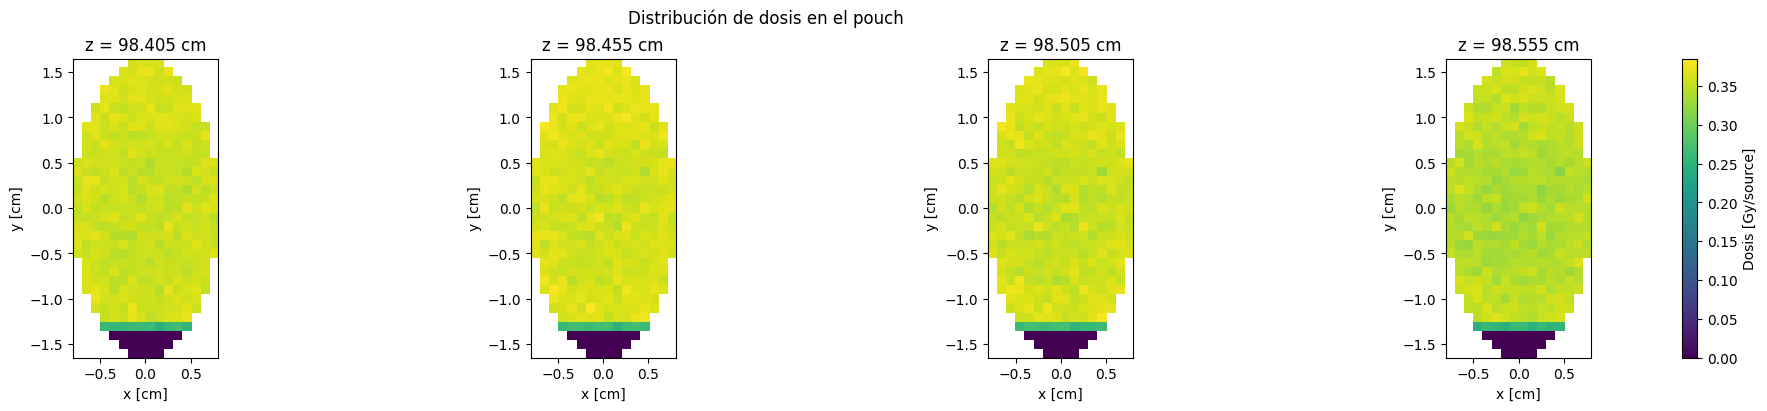

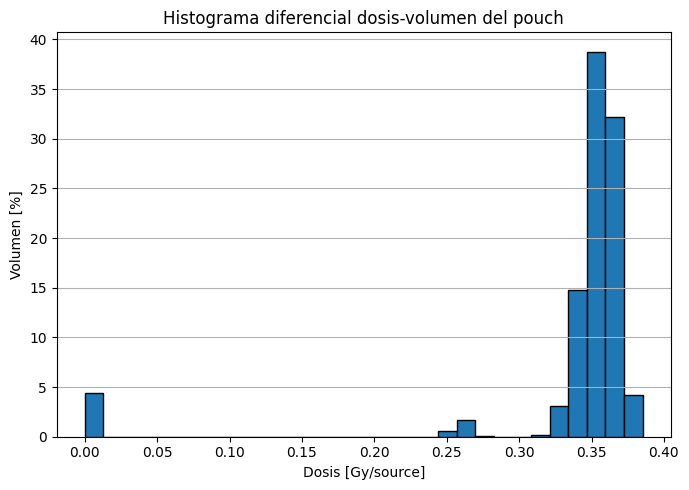

In [48]:
indices = np.argwhere(mascara_pouch)

df_pouch = pd.DataFrame({
    "ix": indices[:, 0] + 1,
    "iy": indices[:, 1] + 1,
    "iz": indices[:, 2] + 1,
    "x": x_centros[indices[:, 0]],
    "y": y_centros[indices[:, 1]],
    "z": z_centros[indices[:, 2]],
    "dosis_Gy_source": dosissinat[
        indices[:, 0],
        indices[:, 1],
        indices[:, 2]
    ],
    "err_rel": err_relsinat[
        indices[:, 0],
        indices[:, 1],
        indices[:, 2]
    ]
})

display(df_pouch.head(4))


fig, axes = plt.subplots(
    1,
    nz,
    figsize=(5 * nz, 4),
    constrained_layout=True
)

vmin = np.nanmin(dosis_pouchsinat)
vmax = np.nanmax(dosis_pouchsinat)

for iz in range(nz):

    im = axes[iz].imshow(
        dosis_pouchsinat[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(
        f"z = {z_centros[iz]:.3f} cm"
    )

fig.colorbar(
    im,
    ax=axes,
    label="Dosis [Gy/source]"
)

plt.suptitle("Distribución de dosis en el pouch")
plt.show()


bins_dosis = 30

volumen_por_voxel = 100.0 / n_voxeles

volumen_diferencial, bordes = np.histogram(
    data_dosis2sinat,
    bins=bins_dosis,
    weights=np.full(
        n_voxeles,
        volumen_por_voxel
    )
)

centros = 0.5 * (
    bordes[:-1] + bordes[1:]
)

anchos = np.diff(bordes)

plt.figure(figsize=(7, 5))

plt.bar(
    centros,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen [%]")
plt.title(
    "Histograma diferencial dosis-volumen del pouch"
)

plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

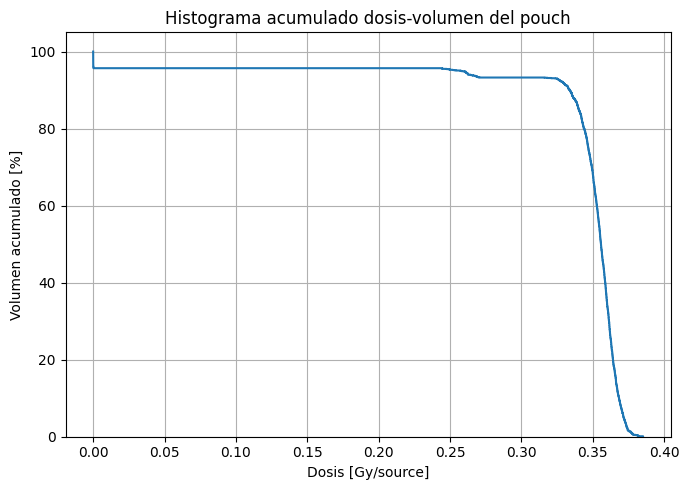

In [49]:
dosis_ordenada = np.sort(
    data_dosis2sinat
)

volumen_acumulado = (
    100.0
    * (n_voxeles - np.arange(n_voxeles))
    / n_voxeles
)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenada,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title(
    "Histograma acumulado dosis-volumen del pouch"
)

plt.grid(True)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Vóxeles originales del pouch: 1648
Vóxeles después del corte: 1536
Vóxeles eliminados: 112


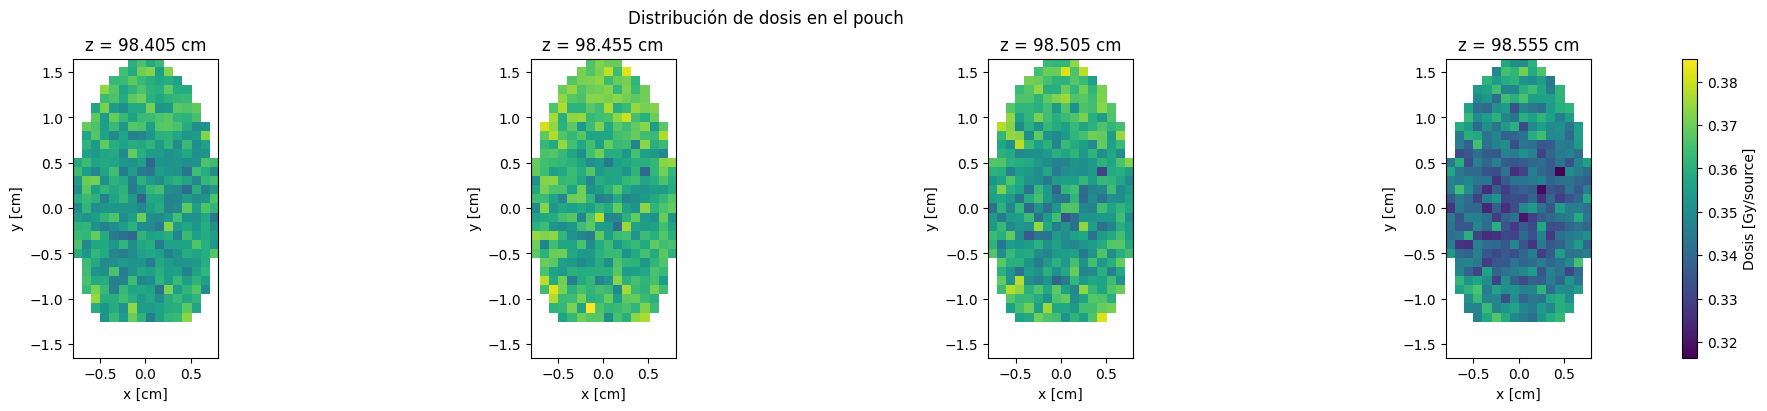

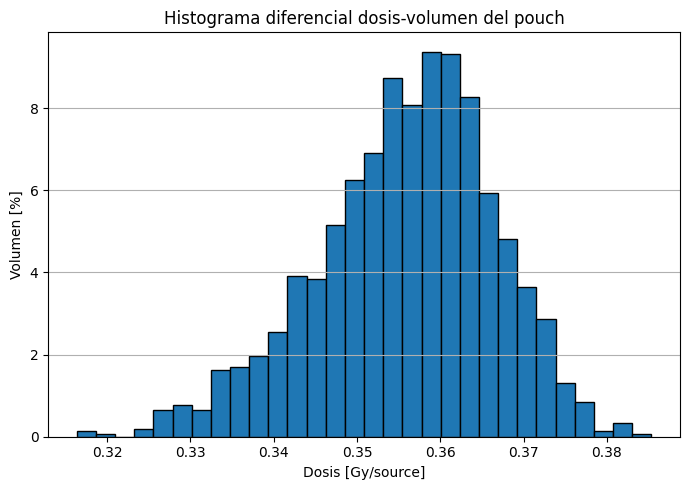

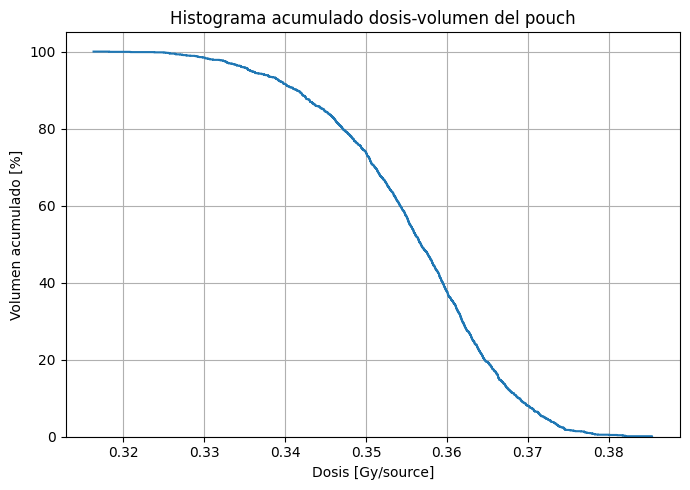

In [50]:
# ============================================================
# Eliminar valores de baja dosis
# ============================================================

corte_dosis = 0.30  # [Gy/source]

dosis_pouch_filtrada = np.where(
    (mascara_pouch) & (dosissinat >= corte_dosis),
    dosissinat,
    np.nan
)

data_dosis_filtrada = dosis_pouch_filtrada[
    ~np.isnan(dosis_pouch_filtrada)
]

n_voxeles_filtrados = len(data_dosis_filtrada)

print("Vóxeles originales del pouch:", len(data_dosis2sinat))
print("Vóxeles después del corte:", n_voxeles_filtrados)
print("Vóxeles eliminados:", len(data_dosis2sinat) - n_voxeles_filtrados)


# ============================================================
# MAPAS 2D
# ============================================================

fig, axes = plt.subplots(
    1,
    nz,
    figsize=(5 * nz, 4),
    constrained_layout=True
)

vmin = np.nanmin(dosis_pouch_filtrada)
vmax = np.nanmax(dosis_pouch_filtrada)

for iz in range(nz):

    im = axes[iz].imshow(
        dosis_pouch_filtrada[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(
        f"z = {z_centros[iz]:.3f} cm"
    )

fig.colorbar(
    im,
    ax=axes,
    label="Dosis [Gy/source]"
)

plt.suptitle("Distribución de dosis en el pouch")
plt.show()


# ============================================================
# DVH DIFERENCIAL
# ============================================================

bins_dosis = 30

volumen_por_voxel = 100.0 / n_voxeles_filtrados

volumen_diferencial, bordes = np.histogram(
    data_dosis_filtrada,
    bins=bins_dosis,
    weights=np.full(
        n_voxeles_filtrados,
        volumen_por_voxel
    )
)

centros = 0.5 * (bordes[:-1] + bordes[1:])
anchos = np.diff(bordes)

plt.figure(figsize=(7, 5))

plt.bar(
    centros,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen del pouch")

plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


# ============================================================
# DVH ACUMULADO
# ============================================================

dosis_ordenada = np.sort(data_dosis_filtrada)

volumen_acumulado = (
    100.0
    * (n_voxeles_filtrados - np.arange(n_voxeles_filtrados))
    / n_voxeles_filtrados
)

plt.figure(figsize=(7, 5))

plt.step(
    dosis_ordenada,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")

plt.grid(True)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

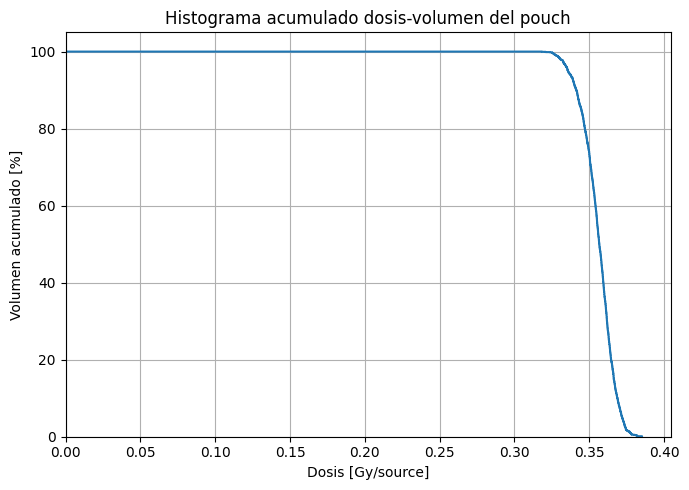

In [51]:
dosis_ordenada = np.sort(data_dosis_filtrada)

n_voxeles = len(dosis_ordenada)

volumen_acumulado = (
    100.0
    * (n_voxeles - np.arange(n_voxeles))
    / n_voxeles
)

dosis_plot = np.concatenate(([0.0], dosis_ordenada))
volumen_plot = np.concatenate(([100.0], volumen_acumulado))

plt.figure(figsize=(7, 5))

plt.step(
    dosis_plot,
    volumen_plot,
    where="post"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen del pouch")

plt.xlim(left=0)
plt.ylim(0, 105)
plt.grid(True)
plt.tight_layout()

plt.show()

## Ultimas dos capas

Capas utilizadas: [98.505 98.555]
Cantidad de vóxeles: 768
Dosis mínima [Gy/source]: 0.31637
Dosis máxima [Gy/source]: 0.38178
Dosis media [Gy/source]: 0.3516470572916666


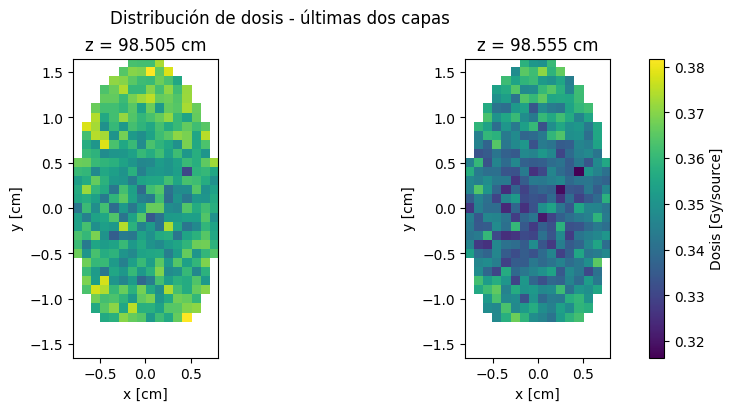

z = 98.505 cm
Dosis mínima: 0.33048 Gy/source
Dosis máxima: 0.38178 Gy/source
Dosis media:  0.35825 Gy/source

z = 98.555 cm
Dosis mínima: 0.31637 Gy/source
Dosis máxima: 0.37059 Gy/source
Dosis media:  0.34504 Gy/source



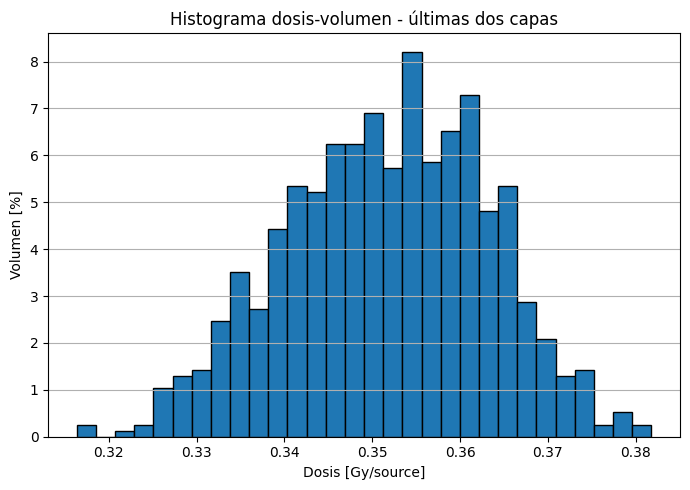

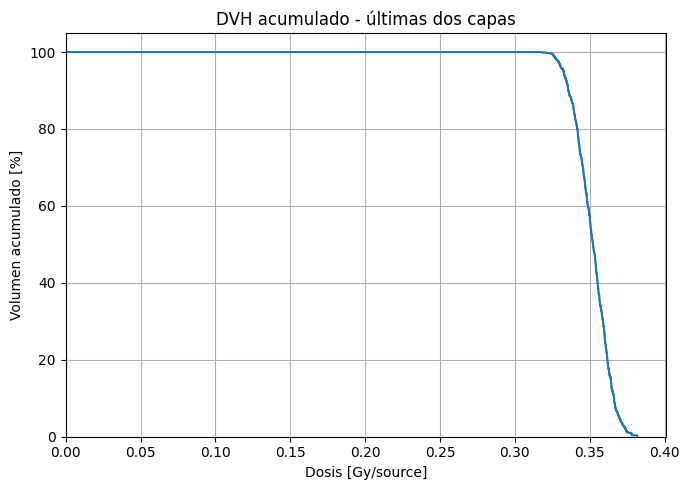

In [54]:
# ============================================================
# ÚLTIMAS DOS CAPAS DEL POUCH
# z = 98.505 cm y z = 98.555 cm
# ============================================================

indices_z = [2, 3]

# Selecciono únicamente las últimas dos capas
dosis_2capas = dosis_pouch_filtrada[:, :, indices_z]

# Datos 1D para los histogramas
data_dosis_2capas = dosis_2capas[
    ~np.isnan(dosis_2capas)
]

n_voxeles_2capas = len(data_dosis_2capas)

print("Capas utilizadas:", z_centros[indices_z])
print("Cantidad de vóxeles:", n_voxeles_2capas)
print("Dosis mínima [Gy/source]:", np.min(data_dosis_2capas))
print("Dosis máxima [Gy/source]:", np.max(data_dosis_2capas))
print("Dosis media [Gy/source]:", np.mean(data_dosis_2capas))


# ============================================================
# MAPAS 2D
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
    constrained_layout=True
)

vmin = np.nanmin(dosis_2capas)
vmax = np.nanmax(dosis_2capas)

for i, iz in enumerate(indices_z):

    im = axes[i].imshow(
        dosis_pouch_filtrada[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[i].set_xlabel("x [cm]")
    axes[i].set_ylabel("y [cm]")
    axes[i].set_title(
        f"z = {z_centros[iz]:.3f} cm"
    )

fig.colorbar(
    im,
    ax=axes,
    label="Dosis [Gy/source]"
)

plt.suptitle("Distribución de dosis - últimas dos capas")
plt.show()

indices_z = [2, 3]

for iz in indices_z:

    datos_capa = dosis_pouch_filtrada[:, :, iz]
    datos_capa = datos_capa[~np.isnan(datos_capa)]

    dosis_min = np.min(datos_capa)
    dosis_max = np.max(datos_capa)
    dosis_media = np.mean(datos_capa)

    print(f"z = {z_centros[iz]:.3f} cm")
    print(f"Dosis mínima: {dosis_min:.5f} Gy/source")
    print(f"Dosis máxima: {dosis_max:.5f} Gy/source")
    print(f"Dosis media:  {dosis_media:.5f} Gy/source")
    print()


# ============================================================
# DVH DIFERENCIAL
# ============================================================

bins_dosis = 30

volumen_por_voxel = 100.0 / n_voxeles_2capas

volumen_diferencial, bordes = np.histogram(
    data_dosis_2capas,
    bins=bins_dosis,
    weights=np.full(
        n_voxeles_2capas,
        volumen_por_voxel
    )
)

centros = 0.5 * (bordes[:-1] + bordes[1:])
anchos = np.diff(bordes)

plt.figure(figsize=(7, 5))

plt.bar(
    centros,
    volumen_diferencial,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen [%]")
plt.title("Histograma dosis-volumen - últimas dos capas")

plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


# ============================================================
# DVH ACUMULADO
# ============================================================

dosis_ordenada = np.sort(data_dosis_2capas)

volumen_acumulado = (
    100.0
    * (n_voxeles_2capas - np.arange(n_voxeles_2capas))
    / n_voxeles_2capas
)

# Extiendo la curva hasta dosis = 0
dosis_plot = np.concatenate((
    [0.0],
    dosis_ordenada
))

volumen_plot = np.concatenate((
    [100.0],
    volumen_acumulado
))

plt.figure(figsize=(7, 5))

plt.step(
    dosis_plot,
    volumen_plot,
    where="post"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("DVH acumulado - últimas dos capas")

plt.xlim(left=0)
plt.ylim(0, 105)
plt.grid(True)
plt.tight_layout()

plt.show()

In [53]:
dosis_min = np.min(data_dosis_2capas)
dosis_max = np.max(data_dosis_2capas)
dosis_media = np.mean(data_dosis_2capas)
desvio = np.std(data_dosis_2capas)

cv = 100 * desvio / dosis_media

print("Dosis mínima [Gy/source]:", dosis_min)
print("Dosis máxima [Gy/source]:", dosis_max)
print("Dosis media [Gy/source]:", dosis_media)
print("Coeficiente de variación [%]:", cv)

Dosis mínima [Gy/source]: 0.31637
Dosis máxima [Gy/source]: 0.38178
Dosis media [Gy/source]: 0.3516470572916666
Coeficiente de variación [%]: 3.2721231456012343
